# 6.4. 실제 이원자 분자

In [9]:
import numpy as np
from scipy.constants import hbar, u, e, c, h

De, we = 37244.0, 2990.95  # cm^-1, HCl 실측값
mu = 1.008 * 34.969 / (1.008 + 34.969) * u

a = (
    2 * np.pi * c * 100 * we * np.sqrt(mu / (2 * De * 100 * h * c))
)
k = 2 * De * 100 * h * c * a**2

print(f"D_e = {De * 100 * h * c/e:.4f} eV")
print(f"a   = {a:.4e} 1/m")
print(f"k   = {k:.1f} N/m   (6.3절에서 구한 값 516.4)")

D_e = 4.6177 eV
a   = 1.8682e+10 1/m
k   = 516.4 N/m   (6.3절에서 구한 값 516.4)


In [13]:
def solve(N, xmin, xmax, potential):
    x = np.linspace(xmin, xmax, N + 2)[1:-1]
    dx = x[1] - x[0]
    D2 = (-2 * np.eye(N) + np.eye(N, k=1) + np.eye(N, k=-1)) / dx**2
    E, psi = np.linalg.eigh(-(hbar**2) / (2 * mu) * D2 + np.diag(potential(x)))
    return x, E, psi


V_morse = lambda x: De * 100 * h * c * (1 - np.exp(-a * x)) ** 2
V_harmonic = lambda x: 0.5 * k * x**2

x, E_m, psi_m = solve(3000, -0.6e-10, 3.5e-10, V_morse)
_, E_h, psi_h = solve(3000, -0.6e-10, 3.5e-10, V_harmonic)

print(f"{'v':>3} {'Morse':>10} {'조화':>8} {'간격(M)':>9} {'간격(H)':>9}")
for v in range(8):
    gap_m = (E_m[v + 1] - E_m[v]) / (100 * h * c)
    gap_h = (E_h[v + 1] - E_h[v]) / (100 * h * c)
    print(
        f"{v:3d} {E_m[v]/ (100 * h * c):10.1f} {E_h[v]/ (100 * h * c):10.1f} {gap_m:10.1f} {gap_h:10.1f}"
    )

  v      Morse       조화     간격(M)     간격(H)
  0     1480.4     1495.5     2870.8     2990.9
  1     4351.2     4486.3     2750.7     2990.8
  2     7101.9     7477.2     2630.5     2990.8
  3     9732.4    10467.9     2510.4     2990.7
  4    12242.8    13458.7     2390.3     2990.6
  5    14633.1    16449.3     2270.2     2990.6
  6    16903.3    19439.9     2150.1     2990.6
  7    19053.4    22430.5     2030.0     2990.8


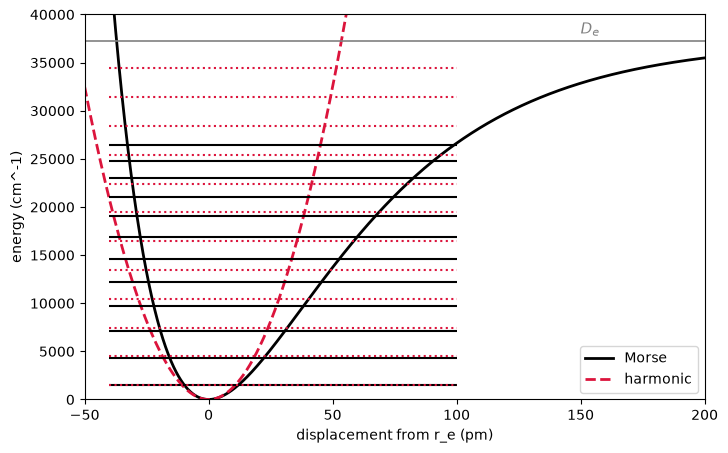

In [32]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(x * 1e12, V_morse(x) / (100 * h * c), color="black", lw=2, label="Morse")
ax.plot(
    x * 1e12,
    V_harmonic(x) / (100 * h * c),
    color="crimson",
    lw=2,
    ls="--",
    label="harmonic",
)

for v in range(12):
    ax.hlines(E_m[v] / (100 * h * c), -40, 100, color="black", lw=1.5)
    ax.hlines(E_h[v] / (100 * h * c), -40, 100, color="crimson", lw=1.5, ls=":")

ax.axhline(De, color="gray", lw=1.2)
ax.text(150, De + 700, "$D_e$", fontsize=11, color="gray")
ax.set_xlim(-50, 200)
ax.set_ylim(0, 40000)
ax.set_xlabel("displacement from r_e (pm)")
ax.set_ylabel("energy (cm^-1)")
ax.legend(fontsize=10)
plt.show()

In [33]:
E_cm = E_m / (100 * h * c)
bound = E_cm[E_cm < De]

print(f"D_e = {De:.0f} cm^-1")
print(f"속박 준위 개수: {len(bound)}개")
print(f"가장 높은 준위: v={len(bound)-1}, E = {bound[-1]:.0f} cm^-1")

D_e = 37244 cm^-1
속박 준위 개수: 24개
가장 높은 준위: v=23, E = 37161 cm^-1


In [37]:
transitions = [(0, 1, "fundamental"), (0, 2, "1st overtone"), (0, 3, "2nd overtone")]

print(f"{'전이':>13} {'Morse 계산':>11} {'HCl 실측':>8}")
observed = {1: 2885.3, 2: 5665.0, 3: 8339.0}
for vi, vf, name in transitions:
    calc = (E_m[vf] - E_m[vi]) / (100 * h * c)
    print(f"{name:>14} {calc:12.1f} {observed[vf]:10.1f}")

           전이    Morse 계산   HCl 실측
   fundamental       2870.8     2885.3
  1st overtone       5621.5     5665.0
  2nd overtone       8252.0     8339.0
